## Import Required Libraries

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load the Preprocessed Dataset

In [7]:
import os

print("Current Directory:")
print(os.getcwd())

Current Directory:
C:\Users\HP\TruthLens


In [8]:
import os

print(os.listdir())

[' report', '.ipynb_checkpoints', '02_eda.ipynb', '03_Model_Training.ipynb', '04_Explainable_AI.ipynb', '1.1.0', 'assets', 'database', 'dataset', 'data_processing', 'eda', 'explainability', 'fake_news_cleaned.csv', 'fake_news_training.ipynb', 'main.ipynb', 'models', 'pages', 'requirements.ipynb', 'results', 'test_dataset.py', 'Untitled Folder']


In [9]:
df = pd.read_csv("dataset/final_dataset.csv")

df.head()

,id,news_url,title,tweet_ids,label
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...,0
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...,0
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...,0
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...,0
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...,0


## Dataset Information

In [14]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Shape: (23196, 5)

Class Distribution:
label
1    17441
0     5755
Name: count, dtype: int64


## Define Features and Labels

In [15]:
X = df["title"]

y = df["label"]

## Split Dataset into Training and Testing Sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 18556
Testing Samples: 4640


## Convert Text Data into TF-IDF Features

In [17]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(18556, 5000)
(4640, 5000)


## Train Linear SVM Model

In [18]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC()

## Generate Predictions

In [19]:
y_pred = svm_model.predict(X_test_tfidf)

## Evaluate Model Performance

In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred
))


Accuracy: 0.8407327586206896

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.58      0.64      1151
           1       0.87      0.93      0.90      3489

    accuracy                           0.84      4640
   macro avg       0.80      0.75      0.77      4640
weighted avg       0.83      0.84      0.83      4640



## Generate Confusion Matrix

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 662  489]
 [ 250 3239]]


## Visualize Confusion Matrix

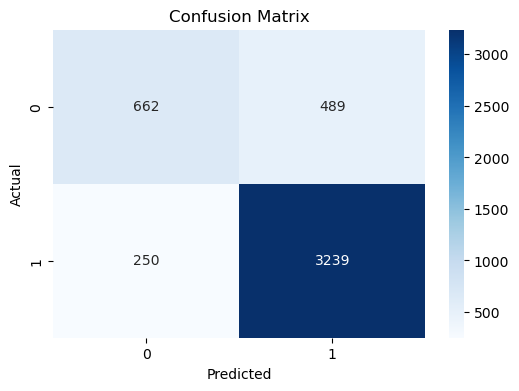

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Save Model and TF-IDF Vectorizer


In [23]:
import pickle

with open("../models/svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("../models/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model Saved Successfully")

Model Saved Successfully


# Import Passive Aggressive Classifier

In [24]:
from sklearn.linear_model import PassiveAggressiveClassifier

## Train Passive Aggressive Model

In [25]:
pac_model = PassiveAggressiveClassifier(
    max_iter=1000,
    random_state=42
)

pac_model.fit(
    X_train_tfidf,
    y_train
)

PassiveAggressiveClassifier(random_state=42)

## Generate Predictions

In [26]:
pac_pred = pac_model.predict(
    X_test_tfidf
)

## Evaluate Passive Aggressive Model

In [27]:
pac_accuracy = accuracy_score(
    y_test,
    pac_pred
)

print(
    "PAC Accuracy:",
    pac_accuracy
)

print(
    classification_report(
        y_test,
        pac_pred
    )
)

PAC Accuracy: 0.8019396551724138
              precision    recall  f1-score   support

           0       0.60      0.61      0.60      1151
           1       0.87      0.87      0.87      3489

    accuracy                           0.80      4640
   macro avg       0.73      0.74      0.74      4640
weighted avg       0.80      0.80      0.80      4640



# Compare Models

In [28]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred
)

pac_accuracy = accuracy_score(
    y_test,
    pac_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Passive Aggressive"
    ],
    "Accuracy": [
        svm_accuracy,
        pac_accuracy
    ]
})

comparison

,Model,Accuracy
0,Linear SVM,0.840733
1,Passive Aggressive,0.801940


## Accuracy Comparison Chart

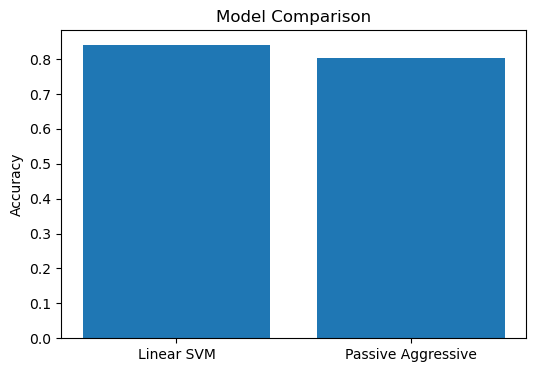

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [30]:
import os

os.makedirs("../models", exist_ok=True)

In [35]:
import pickle

with open("../models/svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

print("SVM Model Saved")

SVM Model Saved


In [37]:
with open("../models/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("TF-IDF Saved")

TF-IDF Saved


In [38]:
with open("../models/pac_model.pkl", "wb") as f:
    pickle.dump(pac_model, f)

print("PAC Model Saved")


PAC Model Saved


In [39]:
print(type(pac_model))


<class 'sklearn.linear_model._passive_aggressive.PassiveAggressiveClassifier'>


In [40]:
import os

print(os.listdir("../models"))

['pac_model.pkl', 'svm_model.pkl', 'tfidf.pkl']
